# 09 Final Descriptive Diagnostics


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 250)
pd.set_option('display.width', 220)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

PANEL_DIR = PROJECT_ROOT / 'data' / 'panel'
FIGURES_DIR = PROJECT_ROOT / 'figures' / '09_notebook_figures'
DOCS_DIR = PROJECT_ROOT / 'docs'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FULL_PANEL_PARQUET = PANEL_DIR / 'monthly_full_analysis_panel_2013_2025.parquet'
FULL_PANEL_CSV = PANEL_DIR / 'monthly_full_analysis_panel_2013_2025.csv'
SHOCK_SUMMARY_CSV = PANEL_DIR / 'full_panel_text_shock_window_summary.csv'
LAG_SUMMARY_CSV = PANEL_DIR / 'lag_diagnostics_descriptive_summary.csv'

OUT_FINAL_DIAG_CSV = PANEL_DIR / 'final_descriptive_diagnostics.csv'

EXPECTED_RANGE = pd.period_range('2013-09', '2025-12', freq='M')
EXPECTED_ROWS = len(EXPECTED_RANGE)

KEY_COLS = [
    'afd_poll_support_mean',
    'nexis_total_results',
    'migration_terms_per_1000_mean',
    'security_terms_per_1000_mean',
    'afd_far_right_terms_per_1000_mean',
    'remigration_democracy_terms_per_1000_mean',
    'negative_threat_terms_per_1000_mean',
]

SHOCKS = {
    'Cologne': pd.Timestamp('2016-01-01'),
    'Chemnitz': pd.Timestamp('2018-08-01'),
    'Correctiv': pd.Timestamp('2024-01-01'),
}

In [2]:
def load_table(parquet_path: Path, csv_path: Path, label: str) -> pd.DataFrame:
    if parquet_path.exists():
        print(f'Load parquet: {label}')
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        print(f'Load csv: {label}')
        return pd.read_csv(csv_path)
    raise FileNotFoundError(f'Missing {label}: {parquet_path} and {csv_path}')

full = load_table(FULL_PANEL_PARQUET, FULL_PANEL_CSV, 'full panel').copy()

if 'year_month' not in full.columns:
    raise ValueError('Full panel missing year_month')

full['year_month'] = full['year_month'].astype(str)
full['month_dt'] = pd.to_datetime(full['year_month'] + '-01', errors='coerce')
if full['month_dt'].isna().any():
    bad = full.loc[full['month_dt'].isna(), 'year_month'].head(10).tolist()
    raise ValueError(f'Unparseable year_month values in full panel: {bad}')

if full['year_month'].duplicated().any():
    dups = full.loc[full['year_month'].duplicated(), 'year_month'].head(10).tolist()
    raise ValueError(f'Full panel has duplicate months: {dups}')

if len(full) != EXPECTED_ROWS:
    raise ValueError(f'Full panel row mismatch: got {len(full)}, expected {EXPECTED_ROWS}')

full_periods = pd.PeriodIndex(full['year_month'], freq='M')
missing_periods = EXPECTED_RANGE.difference(full_periods)
extra_periods = full_periods.difference(EXPECTED_RANGE)
if len(missing_periods) > 0 or len(extra_periods) > 0:
    raise ValueError(
        'Full panel coverage mismatch. '
        f'missing={ [p.strftime("%Y-%m") for p in missing_periods] }, '
        f'extra={ [p.strftime("%Y-%m") for p in extra_periods] }'
    )

missing_required_cols = [c for c in KEY_COLS if c not in full.columns]
if missing_required_cols:
    raise ValueError(f'Full panel missing required key columns: {missing_required_cols}')

missing_counts = {c: int(full[c].isna().sum()) for c in KEY_COLS}
if any(v > 0 for v in missing_counts.values()):
    raise ValueError(f'Full panel has missing values in key columns: {missing_counts}')

full = full.sort_values('month_dt').reset_index(drop=True)

Load parquet: full panel


In [3]:
if not SHOCK_SUMMARY_CSV.exists():
    raise FileNotFoundError(f'Missing shock summary input: {SHOCK_SUMMARY_CSV}')

shock_long = pd.read_csv(SHOCK_SUMMARY_CSV)
required_shock_cols = [
    'shock_label', 'shock_month', 'window_months', 'variable', 'change_post_minus_pre'
]
missing_shock_cols = [c for c in required_shock_cols if c not in shock_long.columns]
if missing_shock_cols:
    raise ValueError(f'Shock summary missing columns: {missing_shock_cols}')

required_shocks = {'Cologne', 'Chemnitz', 'Correctiv'}
found_shocks = set(shock_long['shock_label'].unique())
if found_shocks != required_shocks:
    raise ValueError(f'Shock labels mismatch. found={sorted(found_shocks)}, expected={sorted(required_shocks)}')

required_windows = {3, 6}
found_windows = set(shock_long['window_months'].unique())
if found_windows != required_windows:
    raise ValueError(f'Window mismatch. found={sorted(found_windows)}, expected={sorted(required_windows)}')

shock_long = shock_long.copy()
shock_long['window_label'] = shock_long['window_months'].map({3: 'pm3m', 6: 'pm6m'})

wide = shock_long.pivot_table(
    index='shock_label',
    columns=['variable', 'window_label'],
    values='change_post_minus_pre',
    aggfunc='first'
)
wide.columns = [f'{var}_change_{win}' for var, win in wide.columns]
wide = wide.reset_index()

expected_mechanism = {
    'Cologne': 'Expected: AfD support up; security/public-order framing up around Cologne context.',
    'Chemnitz': 'Expected: strong security and far-right framing surge; limited net polling movement.',
    'Correctiv': 'Expected: AfD support down; remigration/democracy-threat and far-right framing spike.',
}

shock_month_map = {
    'Cologne': '2016-01',
    'Chemnitz': '2018-08',
    'Correctiv': '2024-01',
}


def _v(row, col):
    val = row.get(col, np.nan)
    return float(val) if pd.notna(val) else np.nan


def interpretation_label(shock: str, row: dict) -> str:
    afd6 = _v(row, 'afd_poll_support_mean_change_pm6m')
    sec6 = _v(row, 'security_terms_per_1000_mean_change_pm6m')
    far6 = _v(row, 'afd_far_right_terms_per_1000_mean_change_pm6m')
    rem6 = _v(row, 'remigration_democracy_terms_per_1000_mean_change_pm6m')

    if shock == 'Cologne':
        if afd6 > 0 and sec6 > 0:
            return 'Pattern-consistent: polling increase with stronger security framing.'
        if afd6 > 0:
            return 'Partial: polling increase without a strong parallel security-framing rise.'
        return 'Weak/contrary: expected positive polling shift not sustained in +/-6m summary.'

    if shock == 'Chemnitz':
        if abs(afd6) <= 1.0 and sec6 > 0 and far6 > 0:
            return 'Pattern-consistent: strong framing movement with limited net polling shift.'
        if sec6 > 0 and far6 > 0:
            return 'Partial: framing movement present, polling response not limited.'
        return 'Weak/contrary: mechanism indicators do not rise jointly in +/-6m summary.'

    if shock == 'Correctiv':
        if afd6 < 0 and rem6 > 0 and far6 > 0:
            return 'Pattern-consistent: polling decline with remigration/far-right content surge.'
        if afd6 < 0 and (rem6 > 0 or far6 > 0):
            return 'Partial: polling decline with only one mechanism indicator rising clearly.'
        return 'Weak/contrary: expected negative polling shift with mechanism spike not fully aligned.'

    return 'No label'

rows = []
for shock in ['Cologne', 'Chemnitz', 'Correctiv']:
    rec = {'shock_label': shock, 'shock_month': shock_month_map[shock], 'expected_direction_mechanism': expected_mechanism[shock]}
    if shock in set(wide['shock_label']):
        src = wide.loc[wide['shock_label'] == shock].iloc[0].to_dict()
        for col in [
            'afd_poll_support_mean_change_pm3m', 'afd_poll_support_mean_change_pm6m',
            'migration_terms_per_1000_mean_change_pm3m', 'migration_terms_per_1000_mean_change_pm6m',
            'security_terms_per_1000_mean_change_pm3m', 'security_terms_per_1000_mean_change_pm6m',
            'afd_far_right_terms_per_1000_mean_change_pm3m', 'afd_far_right_terms_per_1000_mean_change_pm6m',
            'remigration_democracy_terms_per_1000_mean_change_pm3m', 'remigration_democracy_terms_per_1000_mean_change_pm6m',
            'negative_threat_terms_per_1000_mean_change_pm3m', 'negative_threat_terms_per_1000_mean_change_pm6m',
        ]:
            rec[col] = src.get(col, np.nan)
    rec['interpretation_label'] = interpretation_label(shock, rec)
    rows.append(rec)

final_diag = pd.DataFrame(rows)
final_diag.to_csv(OUT_FINAL_DIAG_CSV, index=False)

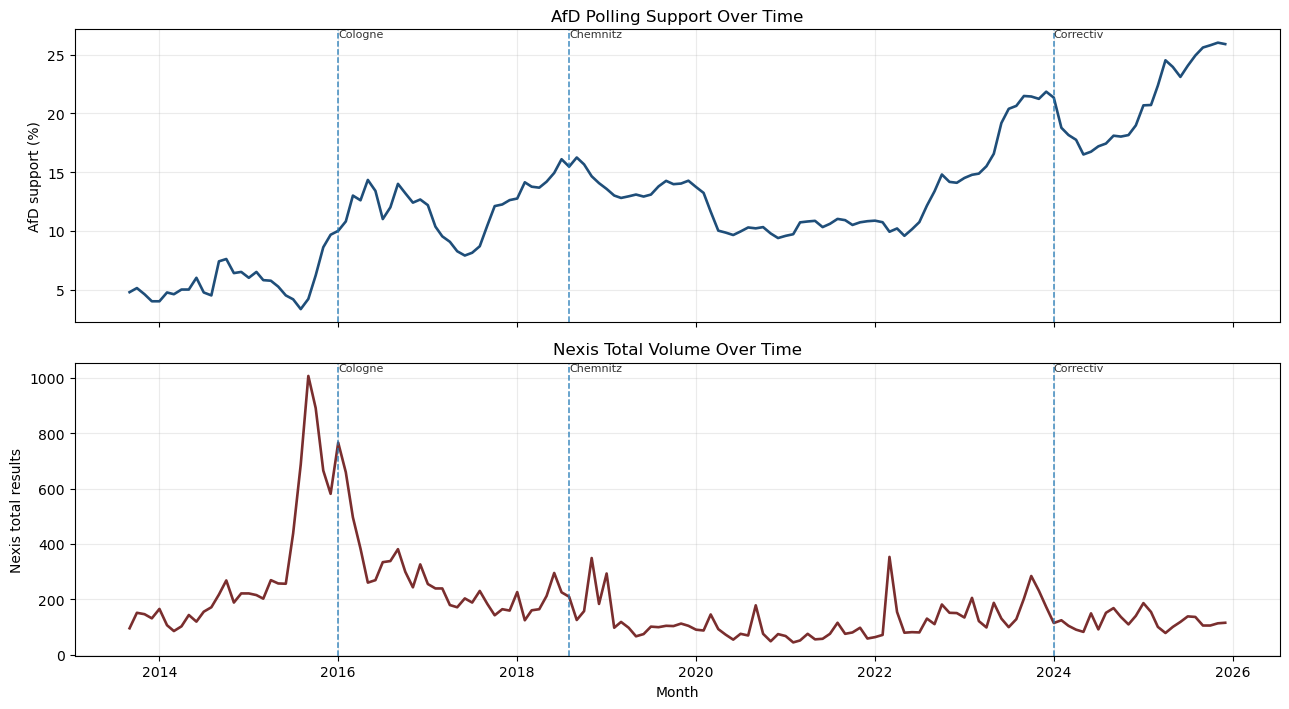

In [4]:
def add_shock_lines_time(ax):
    for label, dt in SHOCKS.items():
        ax.axvline(dt, linestyle='--', linewidth=1.1, alpha=0.85)
        ax.text(dt, ax.get_ylim()[1], label, fontsize=8, va='top', ha='left', alpha=0.8)

fig, axes = plt.subplots(2, 1, figsize=(13, 7.2), sharex=True)

axes[0].plot(full['month_dt'], full['afd_poll_support_mean'], color='#1f4e79', linewidth=1.9)
axes[0].set_title('AfD Polling Support Over Time')
axes[0].set_ylabel('AfD support (%)')
axes[0].grid(alpha=0.25)
add_shock_lines_time(axes[0])

axes[1].plot(full['month_dt'], full['nexis_total_results'], color='#7a2e2e', linewidth=1.9)
axes[1].set_title('Nexis Total Volume Over Time')
axes[1].set_ylabel('Nexis total results')
axes[1].set_xlabel('Month')
axes[1].grid(alpha=0.25)
add_shock_lines_time(axes[1])

fig.tight_layout()
out_overview = FIGURES_DIR / 'overview_afd_support_and_nexis_volume.png'
fig.savefig(out_overview, dpi=160)
plt.show()

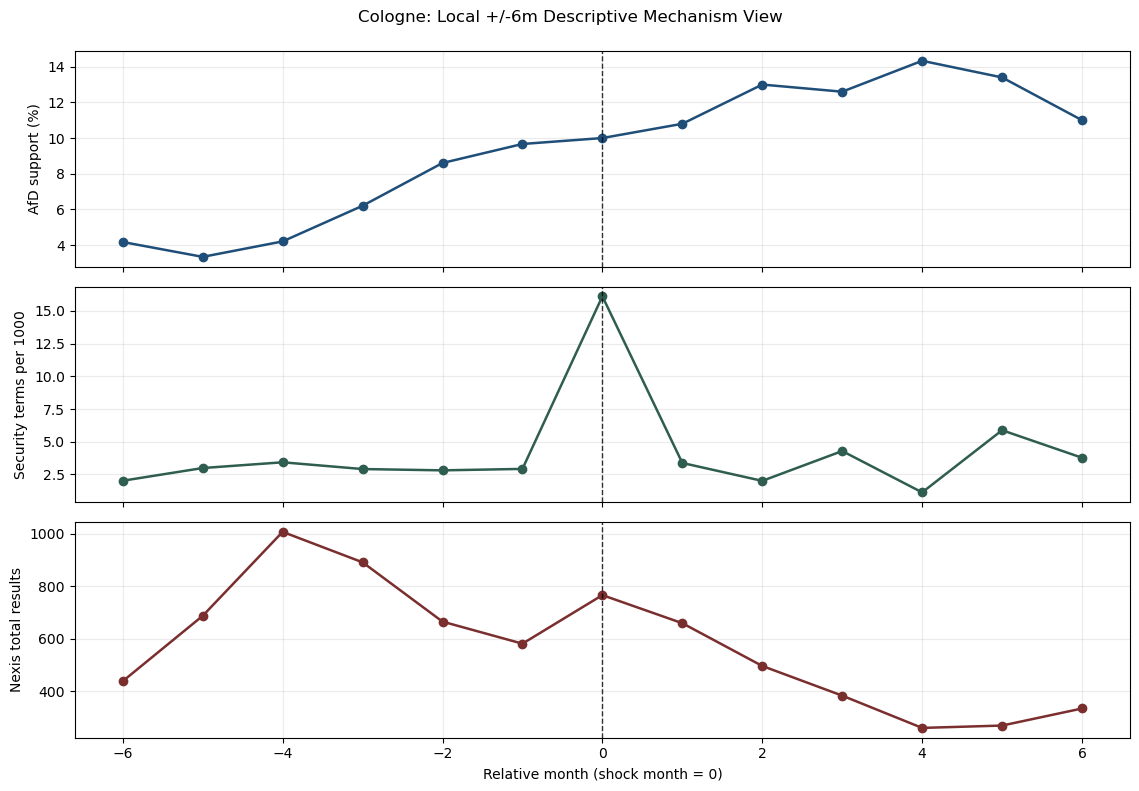

Saved: c:\PythonProjects\AfD-project\figures\09_notebook_figures\cologne_local_mechanism_security.png


In [5]:
def local_window(df: pd.DataFrame, shock_month: pd.Timestamp, win: int = 6) -> pd.DataFrame:
    w = df[(df['month_dt'] >= shock_month - pd.DateOffset(months=win)) & (df['month_dt'] <= shock_month + pd.DateOffset(months=win))].copy()
    w['rel_month'] = ((w['month_dt'].dt.year - shock_month.year) * 12 + (w['month_dt'].dt.month - shock_month.month)).astype(int)
    return w.sort_values('rel_month').reset_index(drop=True)


def plot_local_stacked(w: pd.DataFrame, specs: list[tuple[str, str, str]], title: str, out_path: Path):
    n = len(specs)
    fig, axes = plt.subplots(n, 1, figsize=(11.5, 2.5 * n + 0.4), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, (col, ylab, color) in zip(axes, specs):
        ax.plot(w['rel_month'], pd.to_numeric(w[col], errors='coerce'), marker='o', linewidth=1.8, color=color)
        ax.axvline(0, linestyle='--', linewidth=1.0, color='black', alpha=0.8)
        ax.set_ylabel(ylab)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel('Relative month (shock month = 0)')
    fig.suptitle(title, y=0.995)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.show()
    print('Saved:', out_path)

w_cologne = local_window(full, SHOCKS['Cologne'], win=6)
plot_local_stacked(
    w_cologne,
    [
        ('afd_poll_support_mean', 'AfD support (%)', '#1f4e79'),
        ('security_terms_per_1000_mean', 'Security terms per 1000', '#2f5d50'),
        ('nexis_total_results', 'Nexis total results', '#7a2e2e'),
    ],
    'Cologne: Local +/-6m Descriptive Mechanism View',
    FIGURES_DIR / 'cologne_local_mechanism_security.png'
)


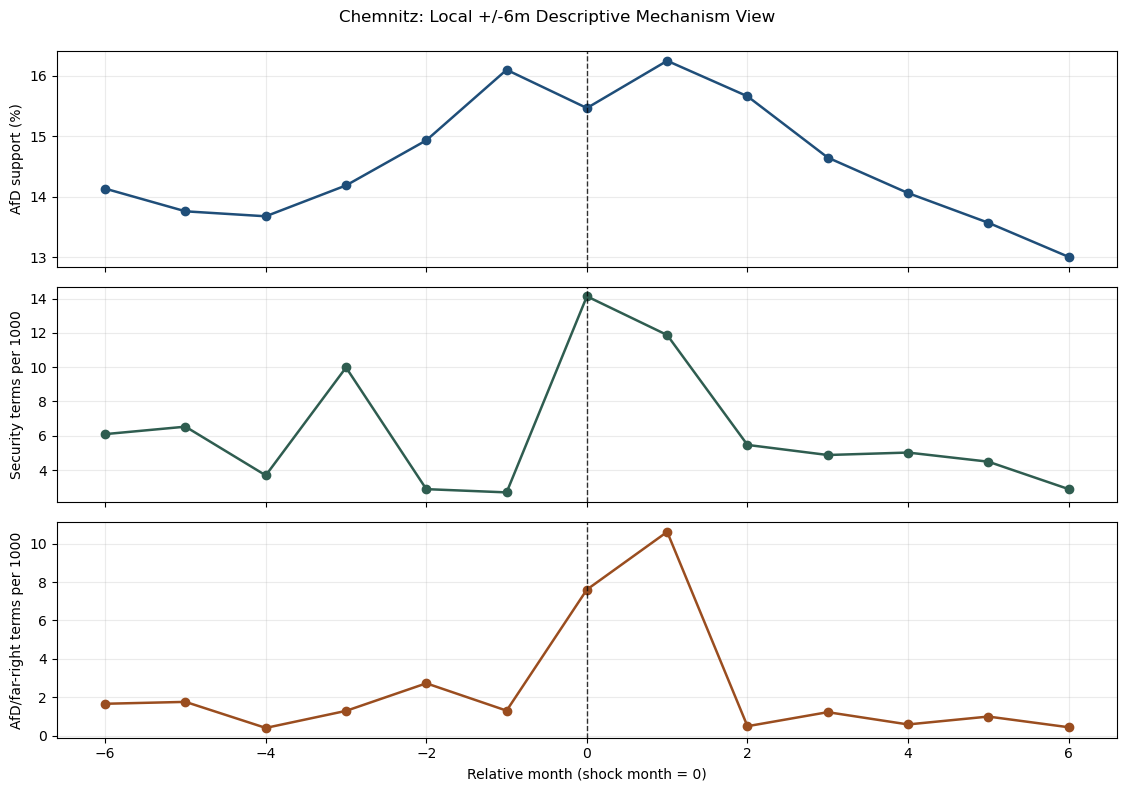

Saved: c:\PythonProjects\AfD-project\figures\09_notebook_figures\chemnitz_local_mechanism_security_far_right.png


In [6]:
w_chemnitz = local_window(full, SHOCKS['Chemnitz'], win=6)
plot_local_stacked(
    w_chemnitz,
    [
        ('afd_poll_support_mean', 'AfD support (%)', '#1f4e79'),
        ('security_terms_per_1000_mean', 'Security terms per 1000', '#2f5d50'),
        ('afd_far_right_terms_per_1000_mean', 'AfD/far-right terms per 1000', '#9a4d1f'),
    ],
    'Chemnitz: Local +/-6m Descriptive Mechanism View',
    FIGURES_DIR / 'chemnitz_local_mechanism_security_far_right.png'
)


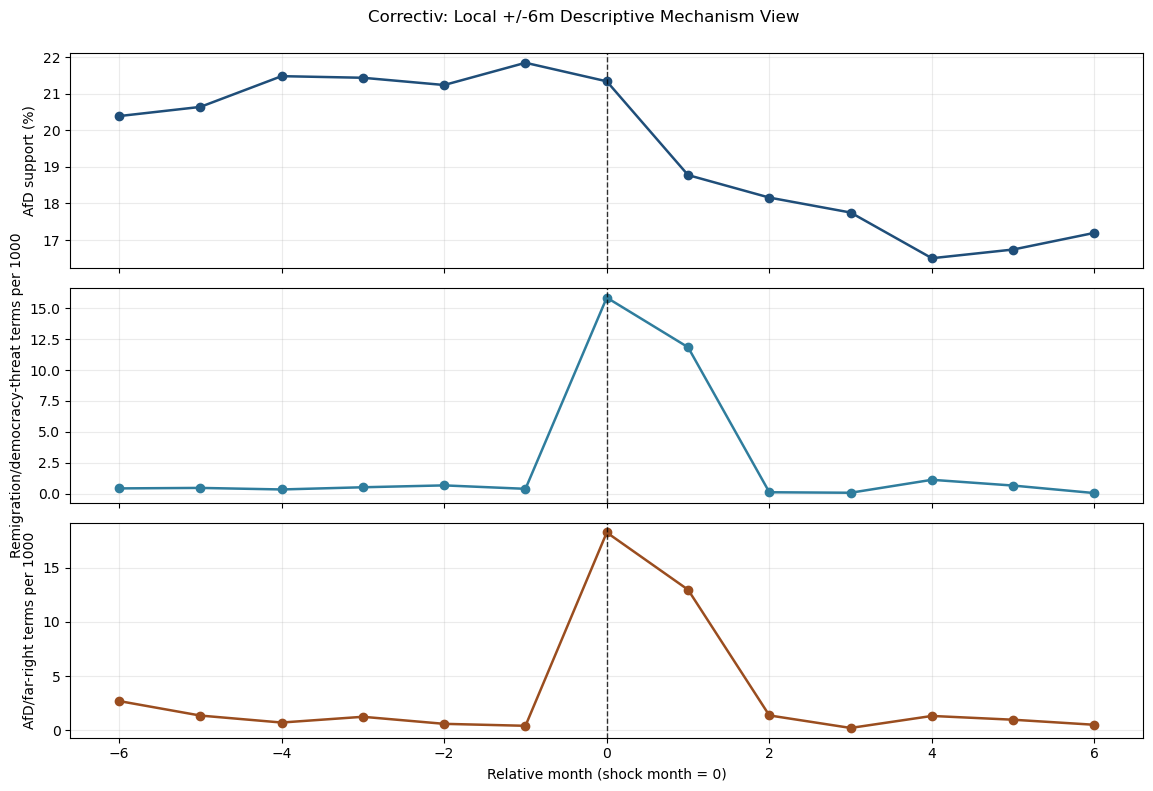

Saved: c:\PythonProjects\AfD-project\figures\09_notebook_figures\correctiv_local_mechanism_remigration_far_right.png


In [7]:
w_correctiv = local_window(full, SHOCKS['Correctiv'], win=6)
plot_local_stacked(
    w_correctiv,
    [
        ('afd_poll_support_mean', 'AfD support (%)', '#1f4e79'),
        ('remigration_democracy_terms_per_1000_mean', 'Remigration/democracy-threat terms per 1000', '#2f7d9d'),
        ('afd_far_right_terms_per_1000_mean', 'AfD/far-right terms per 1000', '#9a4d1f'),
    ],
    'Correctiv: Local +/-6m Descriptive Mechanism View',
    FIGURES_DIR / 'correctiv_local_mechanism_remigration_far_right.png'
)


In [8]:
if LAG_SUMMARY_CSV.exists():
    lag = pd.read_csv(LAG_SUMMARY_CSV)
    need_cols = ['sample', 'lag_months', 'x_variable', 'y_variable', 'correlation', 'n_used']
    miss = [c for c in need_cols if c not in lag.columns]
    if miss:
        raise ValueError(f'Lag summary missing columns: {miss}')

    lag_subset = lag[
        (lag['sample'] == 'combined_all')
        & (lag['x_variable'].str.contains('media_salience_z_lag', na=False))
        & (lag['y_variable'].isin(['afd_poll_support_mean', 'afd_poll_support_change']))
    ].copy()

    if lag_subset.empty:
        print('Lag subset missing.')
    else:
        lag_subset['abs_corr'] = lag_subset['correlation'].abs()
        lag_top = lag_subset.sort_values('abs_corr', ascending=False).head(8)
        print('Lag snapshot:')
        print(lag_top[['sample', 'lag_months', 'x_variable', 'y_variable', 'correlation', 'n_used']].to_string(index=False))
else:
    print('Lag summary missing.')


Lag snapshot:
      sample  lag_months            x_variable              y_variable  correlation  n_used
combined_all           0 media_salience_z_lag0   afd_poll_support_mean    -0.245014     148
combined_all           1 media_salience_z_lag1 afd_poll_support_change     0.244425     147
combined_all           2 media_salience_z_lag2 afd_poll_support_change     0.200125     146
combined_all           1 media_salience_z_lag1   afd_poll_support_mean    -0.198573     147
combined_all           0 media_salience_z_lag0 afd_poll_support_change     0.165381     147
combined_all           2 media_salience_z_lag2   afd_poll_support_mean    -0.158535     146
combined_all           3 media_salience_z_lag3   afd_poll_support_mean    -0.131640     145
combined_all           3 media_salience_z_lag3 afd_poll_support_change     0.114839     145


In [9]:
generated_paths = [
    OUT_FINAL_DIAG_CSV,
    FIGURES_DIR / 'overview_afd_support_and_nexis_volume.png',
    FIGURES_DIR / 'cologne_local_mechanism_security.png',
    FIGURES_DIR / 'chemnitz_local_mechanism_security_far_right.png',
    FIGURES_DIR / 'correctiv_local_mechanism_remigration_far_right.png',
]

for c in KEY_COLS:
    print(f'missing {c}:', int(full[c].isna().sum()))
for p in generated_paths:
    print('-', p, 'exists=', p.exists())

missing afd_poll_support_mean: 0
missing nexis_total_results: 0
missing migration_terms_per_1000_mean: 0
missing security_terms_per_1000_mean: 0
missing afd_far_right_terms_per_1000_mean: 0
missing remigration_democracy_terms_per_1000_mean: 0
missing negative_threat_terms_per_1000_mean: 0
- c:\PythonProjects\AfD-project\data\panel\final_descriptive_diagnostics.csv exists= True
- c:\PythonProjects\AfD-project\figures\09_notebook_figures\overview_afd_support_and_nexis_volume.png exists= True
- c:\PythonProjects\AfD-project\figures\09_notebook_figures\cologne_local_mechanism_security.png exists= True
- c:\PythonProjects\AfD-project\figures\09_notebook_figures\chemnitz_local_mechanism_security_far_right.png exists= True
- c:\PythonProjects\AfD-project\figures\09_notebook_figures\correctiv_local_mechanism_remigration_far_right.png exists= True
